(C) 2025 Gerold Baier, University College London

# Two Nonlinear Two-Population Oscillators with Periodic Perturbation
## Model

The two populations' temporal dynamics (change of state) is described by two first-order nonlinear differential equations. Here we have two coupled units:

$$ \frac{dEx_1}{dt}      = (h_{ex}      - Ex_1    - c_2*sigmoid(In_1) + c_{EE}*sigmoid((Ex_1 + 
frac_E*Ex_2))  + pert)*\tau_{ex}$$
$$ \frac{dIn_1}{dt} \,\, = (h_{in} \,\, - In_1 \, - c_4*sigmoid(In_1) + c_{EI}*sigmoid((Ex_1 + 
frac_I*Ex_2)))*\tau_{in}$$

$$ \frac{dEx_2}{dt}      = (h_{ex}      - Ex_2    - c_2*sigmoid(In_2) + c_{EE}*sigmoid((Ex_2 + 
frac_E*Ex_1)))*\tau_{ex}$$
$$ \frac{dIn_2}{dt} \,\, = (h_{in} \,\, - In_2 \, - c_4*sigmoid(In_2) + c_{EI}*sigmoid((Ex_2 + 
frac_I*Ex_1)))*\tau_{in}$$

$Ex_i$ and $In_i$ are variables that change with time $t$ and represent the excitatory and inhibitory population, respectively.

$h_{ex}$ and $h_{in}$ are constant inputs to the populations. 

$c_2$ and $c_4$ are model parameters representing internal inhibitory coupling. 

$\tau_{ex}$ and $\tau_{in}$ are the poulation time constants.

$c_{EE}$ and $c_{EI}$ are self- and between population excitatory coupling parameters.

_pert_ represents external perturbation.

Function _sigmoid_ is a continuous step function, conmputationally implemented as tangens hyperbolicus.


In [5]:
from scipy.integrate import odeint

from numpy import tanh, mod, linspace, around, zeros, mod, asarray
from numpy import sin, pi, var, ndarray, flip, arange

from numpy.random import default_rng, seed

from matplotlib.pyplot import subplots

import sk_dsp_comm.sigsys as ss

from scipy.signal import find_peaks

from itertools import product


# Time Series

In [67]:
def sigmoid(u):
    return tanh(u)

def oscillator(t, y, N, h_ex, h_in, pars, frac_E, frac_I, sr, time_stop, pert):
               
    tau_ex, tau_in, c2, c4, c_EE, c_EI = pars

    if len(pert) == 0:

        dydt = (

        
            (h_ex - y[0] - c2*sigmoid(y[1]) + c_EE*sigmoid(y[0]+frac_E*y[2]))*tau_ex,
             
            (h_in - y[1] - c4*sigmoid(y[1]) + c_EI*sigmoid(y[0]+frac_I*y[2]))*tau_in,

             
            (h_ex - y[2] - c2*sigmoid(y[3]) + c_EE*sigmoid(y[2]+frac_E*y[0]))*tau_ex,
            
            (h_in - y[3] - c4*sigmoid(y[3]) + c_EI*sigmoid(y[2]+frac_I*y[0]))*tau_in
           )
        
        return dydt


    else:

        time_index = int(t*sr)

        if time_index >= time_stop*sr:

            dydt = zeros(2*N)

            return dydt


        else:
            
            dydt = (

                (pert[time_index] - y[0] - c2*sigmoid(y[1]) + c_EE*sigmoid(y[0]+frac_E*y[2]))*tau_ex,
                 
                (h_in             - y[1] - c4*sigmoid(y[1]) + c_EI*sigmoid(y[0]+frac_I*y[2]))*tau_in,

                 
                (h_ex             - y[2] - c2*sigmoid(y[3]) + c_EE*sigmoid(y[2]+frac_E*y[0]))*tau_ex,
                
                (h_in             - y[3] - c4*sigmoid(y[3]) + c_EI*sigmoid(y[2]+frac_I*y[0]))*tau_in
               )

            return dydt


def plot_bifdiagram_scan(results, freq_set):

    if freq_set[-1] < freq_set[0]:
        
        freq_set = flip(freq_set)

    freq_min, freq_max = freq_set[0], freq_set[-1]

    fig, ax  = subplots(nrows=1, figsize=(5, 4))

    for result in results:
    
        results_min_f, results_max_f = result[0], result[1] 
      
        for xe, ye in zip(freq_set, results_max_f[0]):
    
            if not isinstance(ye, ndarray):
                ax.scatter(xe, ye, c='k', s=5)
            else:
                ax.scatter([xe] * len(ye), ye, c='r', s=5, marker='o')
    
        for xe, ye in zip(freq_set, results_min_f[0]):
    
            if not isinstance(ye, ndarray):
                ax.scatter(xe, ye, c='k', s=5)
            else:
                ax.scatter([xe] * len(ye), ye, c='b', s=5, marker='x')
    
        ax.set_xticks(linspace(freq_min, freq_max, 5));
        ax.set_xticklabels([]);
    
        ax.set_ylabel('Ex', fontsize=14)
    
        y_min, y_max = ax.get_ylim()

        # y_min, y_max = 0.5, 1.5

        ax.set_ylim(y_min, y_max)
        ax.set_yticks(linspace(y_min, y_max, 3))
        ax.set_yticklabels(around(linspace(y_min, y_max, 3)), fontsize=12)

    ax.set_xticks(linspace(freq_min, freq_max, 5));
    ax.set_xticklabels(around(linspace(freq_min, freq_max, 5), 2), fontsize=12);
    
    ax.set_xlabel('Parameter', fontsize=16)

    fig.tight_layout()
    
    return fig, ax


def plot_bifdiagram(results_min_f, results_max_f, 
                    par_set):
    
    N = len(results_min_f)

    fig, ax = subplots(figsize=(6, 4))

    for xe, ye in zip(par_set, results_max_f[0]):

        if not isinstance(ye, ndarray):
            ax.scatter(xe, ye, c='r', s=6, marker='D')
        else:
            ax.scatter([xe] * len(ye), ye, s=3, c='k', marker='D')

    for xe, ye in zip(par_set, results_min_f[0]):

        if not isinstance(ye, ndarray):
            ax.scatter(xe, ye, c='r', s=6, marker='d')
        else:
            ax.scatter([xe] * len(ye), ye, s=3, c='gray', marker='d')


    ax.set_xticks(linspace(par_set[0], par_set[-1], 5));
    ax.set_xticklabels(around(linspace(par_set[0], par_set[-1], 5), 2), fontsize=16);
    ax.set_xlabel('Parameter', fontsize=16)

    ax.set_ylabel('EX', fontsize=14)

    y_min, y_max = ax.get_ylim()

    ax.set_yticks(linspace(y_min, y_max, 3));
    ax.set_yticklabels(around(linspace(y_min, y_max, 3),2), fontsize=14);

    fig.tight_layout()
    
    return fig, ax

End of run: [np.float64(1.492), np.float64(-2.536), np.float64(-0.631), np.float64(-10.742)]



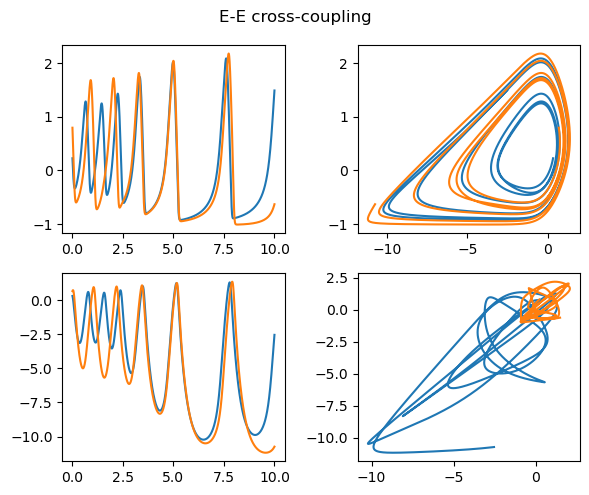

In [7]:
N = 2

# Input parameter
h_ex_0 = -7.
h_in_0 = -4.0

# Oscillator parameters
pars = (1, 2.5, 10, 0, 5, 10) # Homoclinic
# pars = (1, 1.5, 10, 0, 5, 10) # SNIC
# t_ex, t_in, c2, c4, cc_EE, cc_EI

# Strong synchronisation
# frac_E, frac_I = 0.5, 0.0 # < 1. 0 means no coupling

# Temporary desynchronisation
# frac_E, frac_I = 0.0, 0.5 # < 1. 0 means no coupling

frac_E, frac_I = 0.1, 0.0 # < 1. 0 means no coupling

# Initial conditions
SEED = 12345
rng  = default_rng(SEED)
y_ini = rng.uniform(size=2*N)

# Time array
time_stop = 10
sr        = 1000
time      = linspace(start=0, stop=time_stop, num=time_stop*sr)

pulse = []

# Simulation
y = odeint(func=oscillator, y0=y_ini, t=time, 
          args=(N, h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pulse), 
          hmax=0.1)

# Resetting of initial conditions
y_ini = y[-1, :]

# Show final values of all variables
print('End of run:', list(around(y[-1,:],3)))
print('')

fig, ax = subplots(ncols=2, nrows=2, figsize=(6, 5))

ax[0, 0].plot(time, y[:, [0, 2]]);
ax[0, 1].plot(y[:, [1, 3]], y[:, [0, 2]]);
ax[1, 0].plot(time, y[:, [1, 3]]);
ax[1, 1].plot(y[:, [1, 0]], y[:, [3, 2]]);

if frac_E > 0 and frac_I == 0:
    
    chars = 'E-E cross-coupling'
    fig.suptitle(chars)

elif frac_E == 0 and frac_I > 0:
    
    chars = 'E-I cross-coupling'
    fig.suptitle(chars)

elif frac_E > 0 and frac_I > 0:
    
    chars = 'E-E and E-I cross-coupling'
    fig.suptitle(chars)

else:
    
    chars = 'No coupling'
    fig.suptitle(chars)

# elif pars[3] == 10 and pars[6] > 0:
    
#     chars = 'Fast with E-E coupling'
#     fig.suptitle(chars)

# elif pars[3] == 10 and pars[7] > 0:
    
#     chars = 'Fast with E-I coupling'
#     fig.suptitle(chars)
    
fig.tight_layout()



# Bifurcation Diagram h_ex

In [8]:
# Bifurcation parameter set
steps = 20

par_min, par_max = -6.6, -7.4

par_set = linspace(par_min, par_max, steps)

# Time array
time_stop = 500
time = linspace(start=0, stop=time_stop, num=time_stop*sr)

results_min_f      = dict()
results_min_inds_f = dict()
results_max_f      = dict()
results_max_inds_f = dict()

rows = time.size

pulse = []

# Simulation "forward"
for par in par_set:
      
    y_pert = odeint(func=oscillator, y0=y_ini, t=time, 
                  args=(N, par, h_in_0, pars, frac_E, frac_I, sr, time_stop, pulse), 
                  hmax=0.1)

    for num, series in enumerate(y_pert[rows//2:,:-1:2].T):
                
        if var(series) < 0.0001:
    
            if num not in results_min_f:
                
                results_min_f[num]      = [series[-1]]
                results_min_inds_f[num] = [0]    
               
            else:
                results_min_f[num].append(series[-1])
                results_min_inds_f[num].append(0)    

            if num not in results_max_f:
                
                results_max_f[num]      = [series[-1]]
                results_max_inds_f[num] = [0]    
               
            else:
                results_max_f[num].append(series[-1])
                results_max_inds_f[num].append(0)    

        else:
            
            y_f_max_inds = find_peaks(series, distance=100)
            y_f_maxs     = series[y_f_max_inds[0]]

            y_f_min_inds = find_peaks(-series, distance=100)
            y_f_mins     = series[y_f_min_inds[0]]

            if num not in results_min_f:

                results_min_f[num]      = [y_f_mins]
                results_min_inds_f[num] = [y_f_min_inds]
                
                results_max_f[num]      = [y_f_maxs]
                results_max_inds_f[num] = [y_f_max_inds]

            else:

                results_min_f[num].append(y_f_mins)
                results_min_inds_f[num].append(y_f_min_inds)
                
                results_max_f[num].append(y_f_maxs)
                results_max_inds_f[num].append(y_f_max_inds)


    if par != par_set[-1]:
        
        y_ini = y_pert[-1, :]

print('')
print('Scan complete!', list(around(y_pert[-1,:],3)))
print('')


Scan complete! [np.float64(-2.343), np.float64(-13.817), np.float64(-2.343), np.float64(-13.817)]



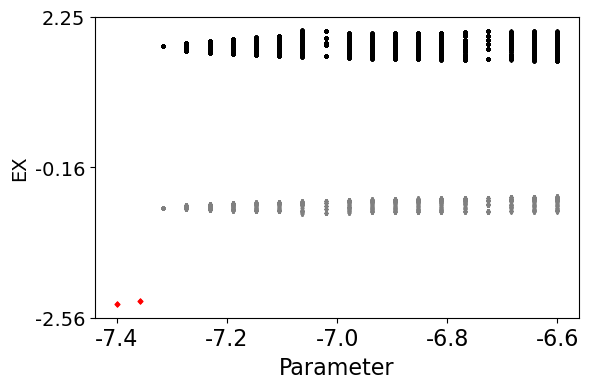

In [9]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)


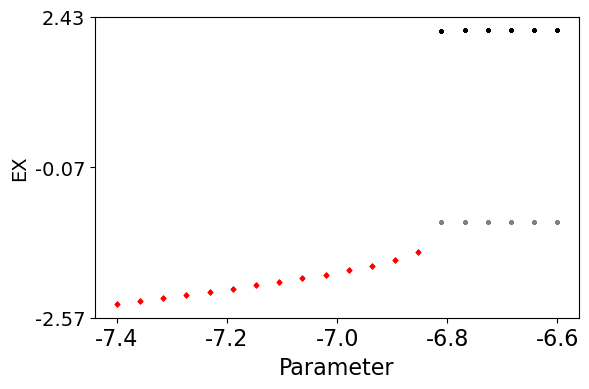

In [44]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)


# Bifurcation Diagram coup_EE

In [27]:
h_ex_0 = -6.8

# Bifurcation parameter set
steps = 10

par_min, par_max = 0., 0.2

par_set = linspace(par_min, par_max, steps)

# Time array
time_stop = 500
time = linspace(start=0, stop=time_stop, num=time_stop*sr)

results_min_f      = dict()
results_min_inds_f = dict()
results_max_f      = dict()
results_max_inds_f = dict()

rows = time.size

pulse = []

# Simulation "forward"
for par in par_set:
      
    y_pert = odeint(func=oscillator, y0=y_ini, t=time, 
                  args=(N, h_ex_0, h_in_0, pars, par, frac_I, sr, time_stop, pulse), 
                  hmax=0.1)

    for num, series in enumerate(y_pert[rows//2:,:-1:2].T):
                
        if var(series) < 0.0001:
    
            if num not in results_min_f:
                
                results_min_f[num]      = [series[-1]]
                results_min_inds_f[num] = [0]    
               
            else:
                results_min_f[num].append(series[-1])
                results_min_inds_f[num].append(0)    

            if num not in results_max_f:
                
                results_max_f[num]      = [series[-1]]
                results_max_inds_f[num] = [0]    
               
            else:
                results_max_f[num].append(series[-1])
                results_max_inds_f[num].append(0)    

        else:
            
            y_f_max_inds = find_peaks(series, distance=100)
            y_f_maxs     = series[y_f_max_inds[0]]

            y_f_min_inds = find_peaks(-series, distance=100)
            y_f_mins     = series[y_f_min_inds[0]]

            if num not in results_min_f:

                results_min_f[num]      = [y_f_mins]
                results_min_inds_f[num] = [y_f_min_inds]
                
                results_max_f[num]      = [y_f_maxs]
                results_max_inds_f[num] = [y_f_max_inds]

            else:

                results_min_f[num].append(y_f_mins)
                results_min_inds_f[num].append(y_f_min_inds)
                
                results_max_f[num].append(y_f_maxs)
                results_max_inds_f[num].append(y_f_max_inds)


    if par != par_set[-1]:
        
        y_ini = y_pert[-1, :]

print('')
print('Scan complete!', list(around(y_pert[-1,:],3)))
print('')


Scan complete! [np.float64(0.974), np.float64(-5.029), np.float64(0.974), np.float64(-5.029)]



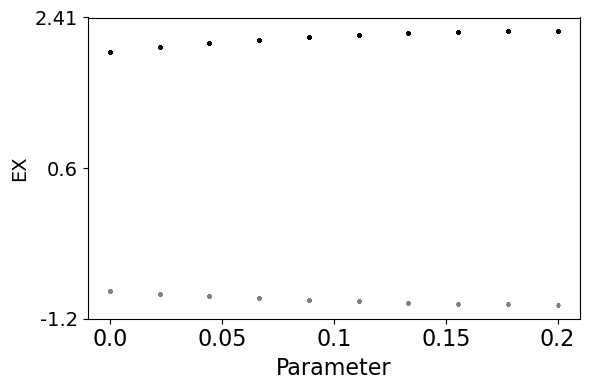

In [28]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)


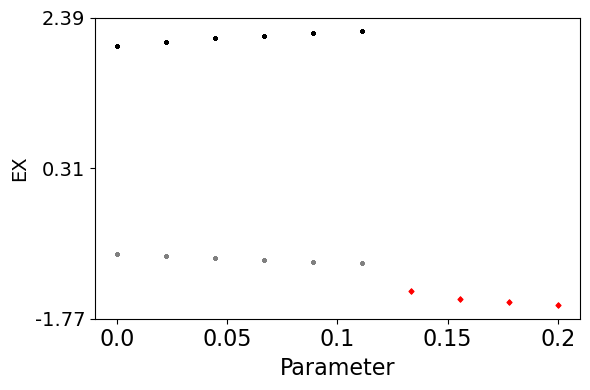

In [24]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)


In [50]:
y_ini

array([0.22733602, 0.31675834, 0.79736546, 0.67625467])

# 2 and 3 D Parameter Scan

Performing 3D parameter scan...


h_ex_1 progress: 100%|██████████| 15/15 [02:42<00:00, 10.84s/it]

Scan completed!


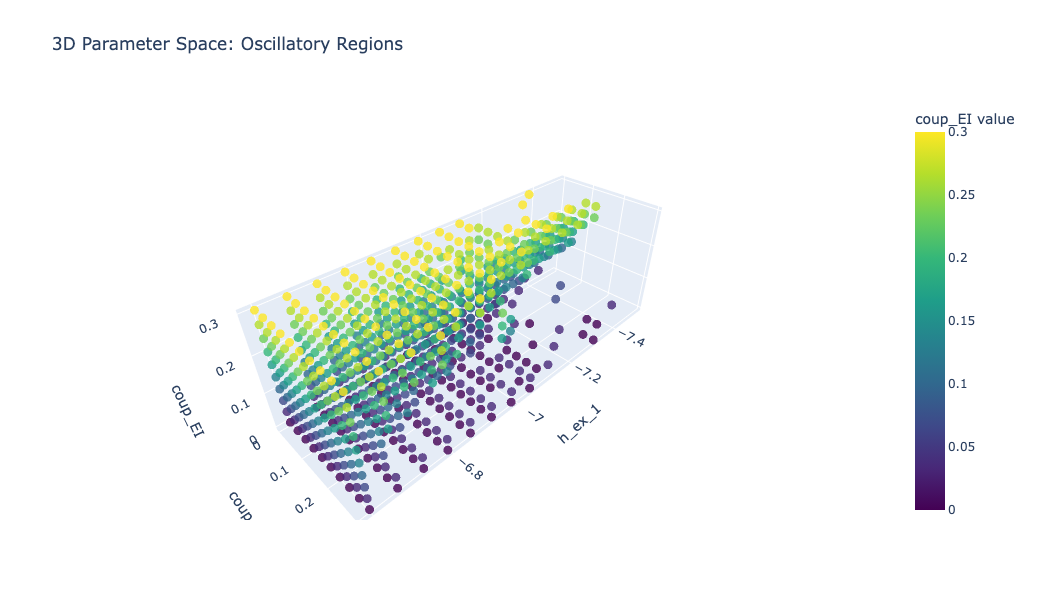

IndexError: index 11 is out of bounds for axis 2 with size 10

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from tqdm import tqdm


def detect_oscillation(solution, threshold_peaks=3, prominence_factor=0.01):
    """
    Detect if the solution exhibits oscillations by looking for multiple peaks
    in the Ex variable after transients have decayed.
    """
    # Use the second half of the time series to avoid transients
    t = solution.t
    Ex = solution.y[0]
    
    # Focus on the second half to avoid initial transients
    start_idx = len(t) // 2
    t_steady = t[start_idx:]
    Ex_steady = Ex[start_idx:]
    
    if len(Ex_steady) < 50:  # Not enough points
        return False
    
    # Calculate prominence for peak detection
    Ex_range = np.max(Ex_steady) - np.min(Ex_steady)
    prominence = Ex_range * prominence_factor

    # Find peaks
    peaks, _ = find_peaks(Ex_steady, distance=20, prominence=prominence)
    
    # Minimum number of peaks
    return len(peaks) >= threshold_peaks


def analyze_parameter_point(h_ex_1_val, coup_EE_val, coup_EI_val, other_params, t_span=(0, 20)):
    """Analyze a single point in parameter space"""
    try:
        solution = solve_ivp(fun=oscillator, t_span=t_span, y0=y_ini,
            args=(N, h_ex_1_val,  h_in_0, other_params, coup_EE_val, coup_EI_val, sr, t_span[1], pulse), 
            method='BDF', max_step=0.1, rtol=1e-6
        )

        # y0 = solution.y[:, -1]
        
        if solution.success:
            return detect_oscillation(solution)
        else:
            return False
    except:
        return False

# Fixed parameters
other_params = (1, 2.5, 10, 0, 5, 10) # Homoclinic

frac_E, frac_I = 0.1, 0.0 # < 1. 0, 0 means no coupling

# Initial conditions
SEED = 12345
rng  = default_rng(SEED)
y_ini = rng.uniform(size=2*N)

# 3D Parameter ranges to explore
h_ex_1_range  = np.linspace(-7.5, -6.6, 15)      
coup_EE_range = np.linspace(0.0, 0.3, 10)    
coup_EI_range = np.linspace(0.0, 0.3, 10)     


# Create the 3D parameter space grid
oscillation_grid_3d = np.zeros((len(h_ex_1_range), len(coup_EE_range), len(coup_EI_range)))

# 3D parameter scan
print("Performing 3D parameter scan...")
total_points = len(h_ex_1_range) * len(coup_EE_range) * len(coup_EI_range)
point_count = 0

for i, h_ex_1_val in enumerate(tqdm(h_ex_1_range, desc="h_ex_1 progress")):
    for j, coup_EE_val in enumerate(coup_EE_range):
        for k, coup_EI_val in enumerate(coup_EI_range):
            if analyze_parameter_point(h_ex_1_val, coup_EE_val, coup_EI_val, other_params):
                oscillation_grid_3d[i, j, k] = 1
    
print("Scan completed!")


# Create interactive 3D plot
def create_3d_oscillation_plot(oscillation_grid_3d, h_ex_1_range, coup_EE_range, coup_EI_range):
    """Create an interactive 3D scatter plot of oscillatory regions"""
    
    # Get coordinates of oscillatory points
    oscillatory_points = np.where(oscillation_grid_3d == 1)
    
    if len(oscillatory_points[0]) == 0:
        print("No oscillatory regions found in the parameter space!")
        return
    
    h_ex_osc    = h_ex_1_range[oscillatory_points[0]]
    coup_EE_osc = coup_EE_range[oscillatory_points[1]] 
    coup_EI_osc = coup_EI_range[oscillatory_points[2]]
    
    # Create 3D scatter plot
    fig = go.Figure(data=[go.Scatter3d(
        x=h_ex_osc,
        y=coup_EE_osc, 
        z=coup_EI_osc,
        mode='markers',
        marker=dict(
            size=5,
            color=coup_EI_osc,  # Color by q value
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title="coup_EI value")
        ),
        name='Oscillatory regions',
        hovertemplate=
        "<b>k_max:</b> %{x:.2f}<br>" +
        "<b>a1:</b> %{y:.2f}<br>" +
        "<b>q:</b> %{z:.2f}<br>" +
        "<extra></extra>"
    )])
    
    fig.update_layout(
        title='3D Parameter Space: Oscillatory Regions',
        scene=dict(
            xaxis_title='h_ex_1',
            yaxis_title='coup_EE',
            zaxis_title='coup_EI',
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            )
        ),
        width=800,
        height=600
    )
    
    return fig

# Create the interactive plot
fig_3d = create_3d_oscillation_plot(oscillation_grid_3d, h_ex_1_range, coup_EE_range, coup_EI_range)
fig_3d.show()

# Additional: Create 2D slices for different q values
def create_2d_slices(oscillation_grid_3d, h_ex_1_range, coup_EE_range, coup_EI_range, num_slices=6):
    """Create 2D slices of the 3D parameter space"""
    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=[f'q = {h_ex_1_val:.2f}' for h_ex_1_val in h_ex_1_range[np.linspace(0, len(h_ex_1_range)-1, num_slices, dtype=int)]]
    )
    
    slice_indices = np.linspace(0, len(h_ex_1_range)-1, num_slices, dtype=int)
    
    for idx, q_idx in enumerate(slice_indices):
        row = idx // 3 + 1
        col = idx % 3 + 1
        
        # Create heatmap for this q slice
        heatmap = go.Heatmap(
            z=oscillation_grid_3d[:, :, q_idx],
            x=coup_EE_range,
            y=coup_EI_range,
            colorscale=['white', 'red'],
            showscale=False
        )
        
        fig.add_trace(heatmap, row=row, col=col)
        
        if row == 2:
            fig.update_xaxes(title_text="coup_EE", row=row, col=col)
        if col == 1:
            fig.update_yaxes(title_text="h_ex_1", row=row, col=col)
    
    fig.update_layout(
        title_text="2D Slices of 3D Parameter Space (Red = Oscillations)",
        height=600
    )
    
    return fig

# Create 2D slice visualization
fig_slices = create_2d_slices(oscillation_grid_3d, h_ex_1_range, coup_EE_range, coup_EI_range)
fig_slices.show()

# Save the 3D data for later use
np.save('Data/oscillation_grid_3d.npy', oscillation_grid_3d)
np.save('Data/h_ex_1_range.npy', h_ex_1_range)
np.save('Data/coup_EE_range.npy', coup_EE_range) 
np.save('Data/coup_EI_range.npy', coup_EI_range)

print("3D data saved to files")

# Periodic Pulse Perturbation

In [20]:
# h_ex_0 = -6.5

# frac_E, frac_I = 0.5, 0.0 # < 1. 0 means no coupling

pulse_wid = 2.
pulse_amp = 1.
pulse_per = 50

# Initial conditions
SEED = 12345
rng  = default_rng(SEED)
y_in = rng.uniform(size=2*N)

# Time array
time_stop = 100
sr        = 1000
time      = linspace(start=0, stop=time_stop, num=time_stop*sr)

rows = time.size

pert = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_per)-(pulse_per)/2-pulse_wid/2, pulse_wid)
    
# Simulation
y_pert = odeint(func=oscillator, y0=y_in, t=time, 
              args=(N, h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
              hmax=0.1)

# Resetting of initial conditions
y_in = y_pert[-1, :]

# Show final values of all variables
print('End of run:', list(around(y_pert[-1,:],2)))
print('')


End of run: [np.float64(-1.3), np.float64(-12.63), np.float64(-1.3), np.float64(-12.63)]



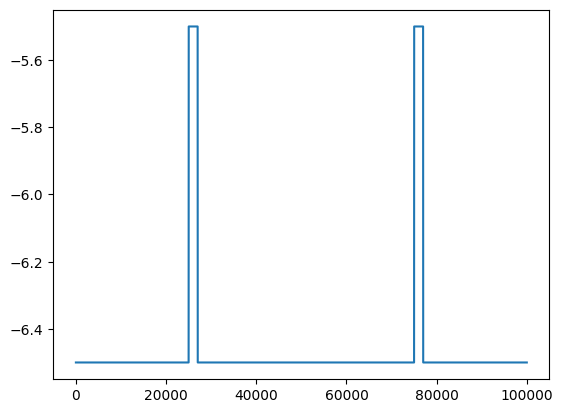

In [22]:
fig, ax = subplots()

ax.plot(pert);

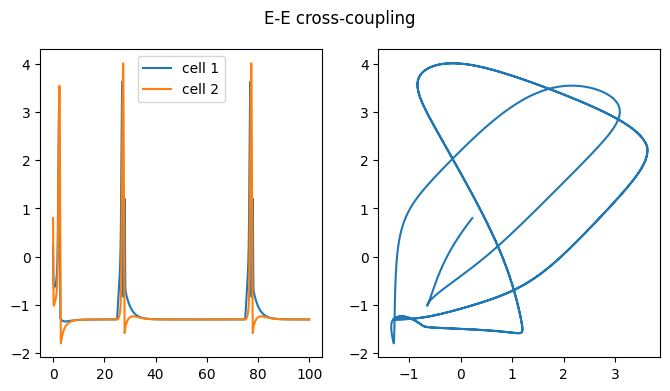

In [24]:
fig, ax = subplots(ncols=2, nrows=1, figsize=(8, 4))

ax[0].plot(time, y_pert[:, 0], label="cell 1");
ax[0].plot(time, y_pert[:, 2], label="cell 2");
ax[0].legend()
ax[1].plot(y_pert[:, 0], y_pert[:, 2]);


if frac_E > 0 and frac_I == 0:
    
    chars = 'E-E cross-coupling'
    fig.suptitle(chars)

elif frac_E == 0 and frac_I > 0:
    
    chars = 'E-I cross-coupling'
    fig.suptitle(chars)

elif frac_E > 0 and frac_I > 0:
    
    chars = 'E-E and E-I cross-coupling'
    fig.suptitle(chars)

else:
    
    chars = 'No coupling'
    fig.suptitle(chars)

In [26]:
# Bifurcation parameter set
steps = 20
freq_min, freq_max = 0.1, 2
freq_set = linspace(freq_min, freq_max, steps)

# Time array
time_stop = 100
sr        = 1000
time      = linspace(start=0, stop=time_stop, num=time_stop*sr)

rows = time.size

pulse_wid = 1.
pulse_amp = 0.25

results = list()

    
results_min_f      = dict()
results_min_inds_f = dict()
results_max_f      = dict()
results_max_inds_f = dict()

# Simulation "forward"
for freq in freq_set:
    
    pert = h_ex_0 + pulse_amp*ss.rect(mod(time, 1/freq)-(1/freq)/2-pulse_wid/2, pulse_wid)

    y_pert = odeint(func=oscillator, y0=y_in, t=time, 
                    args=(N, h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
                    hmax=0.1)

    for num, series in enumerate(y_pert[rows//2:,::2].T):
                
        if var(series) < 0.0001:
    
            if num not in results_min_f:
                
                results_min_f[num]      = [series[-1]]
                results_min_inds_f[num] = [0]    
               
            else:
                results_min_f[num].append(series[-1])
                results_min_inds_f[num].append(0)    

            if num not in results_max_f:
                
                results_max_f[num]      = [series[-1]]
                results_max_inds_f[num] = [0]    
               
            else:
                results_max_f[num].append(series[-1])
                results_max_inds_f[num].append(0)    

        else:
            
            y_f_max_inds = find_peaks(series, distance=100)
            y_f_maxs     = series[y_f_max_inds[0]]

            y_f_min_inds = find_peaks(-series, distance=100)
            y_f_mins     = series[y_f_min_inds[0]]

            if num not in results_min_f:

                results_min_f[num]      = [y_f_mins]
                results_min_inds_f[num] = [y_f_min_inds]
                
                results_max_f[num]      = [y_f_maxs]
                results_max_inds_f[num] = [y_f_max_inds]

            else:

                results_min_f[num].append(y_f_mins)
                results_min_inds_f[num].append(y_f_min_inds)
                
                results_max_f[num].append(y_f_maxs)
                results_max_inds_f[num].append(y_f_max_inds)

        # if par != par_set[-1]:
            
        #     y_in = y_pert[-1, :]

    results.append((results_min_f, results_max_f))

print('')
print('Scan complete!')
print('')



Scan complete!



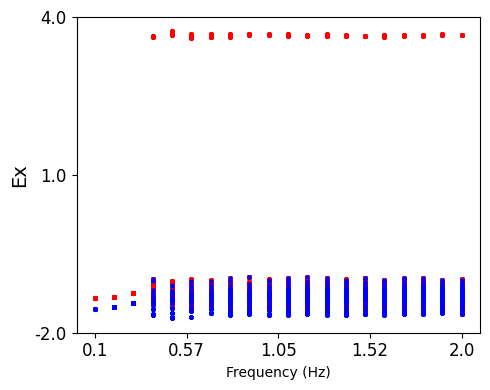

In [28]:
# Plot
fig, ax = plot_bifdiagram_scan(results, freq_set)

    
ax.set_xlabel('Frequency (Hz)', fontsize=10);


fig.tight_layout()

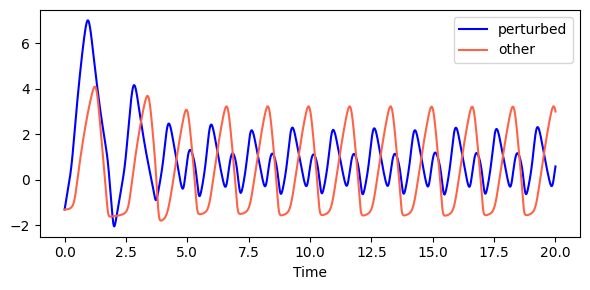

In [30]:
# Time array
time_stop = 20
sr        = 1000
time      = linspace(start=0, stop=time_stop, num=time_stop*sr)

rows = time.size

freq       = 0.5

pulse      = pulse_amp*ss.rect(mod(time, 1/freq)-(1/freq)/2-pulse_wid/2, pulse_wid)

fig, ax = subplots(figsize=(6, 3))

y_pert = odeint(func=oscillator, y0=y_in, t=time, 
                args=(N, h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pulse), 
                hmax=0.1)

ax.plot(time, y_pert[:, 0], c='b',      label='perturbed')
ax.plot(time, y_pert[:, 2], c='tomato', label='other')
ax.legend()

ax.set_xlabel('Time');

fig.tight_layout()


# Pulse Perturbation 2D Parameter Scan

COMPLETE
 


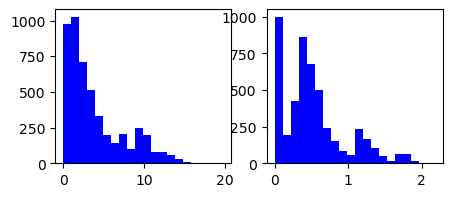

In [50]:
# Initial conditions y_last
y_last = y_ini.copy()

time_stop_pert = 200
sr             = 1000
time           = linspace(start=0, stop=time_stop_pert, num=time_stop_pert*sr)

resolution = 70

pulse_width_min, pulse_width_max = 0.1, 4.1
pulse_ampli_min, pulse_ampli_max = 4, 0.0001

pulse_width = linspace(pulse_width_min, pulse_width_max, resolution)
pulse_ampli = linspace(pulse_ampli_min, pulse_ampli_max, resolution)

pulse_period = 200

results_pert = list()

for pulse in product(pulse_width, pulse_ampli):

    h_ex_p = h_ex_0 + pulse[1]*ss.rect(mod(time, pulse_period)-pulse_period/2+pulse[0]/2, pulse[0])

    y = odeint(func=oscillator, y0=y_last, t=time, args=(N, h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop_pert, h_ex_p),
              hmax=0.1)


    results_pert.append((sum(y[time_stop_pert*sr//2:, 0] - y_last[0])/sr, 
                         sum(y[time_stop_pert*sr//2:, 2] - y_last[2])/sr
                     ))

results_pert_ex1_matrix = asarray(results_pert)[:, 0].reshape(resolution, resolution)
results_pert_ex2_matrix = asarray(results_pert)[:, 1].reshape(resolution, resolution)

print('COMPLETE')
print(' ')

fig, ax = subplots(ncols=2, figsize=(5, 2))

ax[0].hist(results_pert_ex1_matrix.ravel(), bins=20, color='b');

ax[1].hist(results_pert_ex2_matrix.ravel(), bins=20, color='b');


'PulsePert_Homoclinic_frac_E=0.1.png'

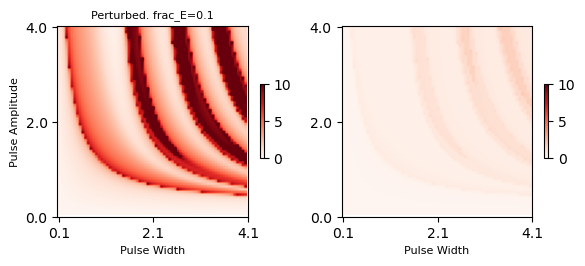

In [56]:
vmin, vmax = 0, 10

fig, ax = subplots(figsize=(6, 4), ncols=2)

im1 = ax[0].imshow(results_pert_ex1_matrix.T, cmap='Reds', vmin=vmin, vmax=vmax)

ax[0].set_xlabel('Pulse Width', fontsize=8)
ax[0].set_ylabel('Pulse Amplitude', fontsize=8)
ax[0].set_xticks(linspace(0, resolution, 3))
ax[0].set_xticklabels(around(linspace(pulse_width_min, pulse_width_max, 3),1))
ax[0].set_yticks(linspace(0, resolution, 3))
ax[0].set_yticklabels(around(linspace(pulse_ampli_min, pulse_ampli_max, 3), 2))
ax[0].set_title('Perturbed. frac_E=0.1', fontsize=8)


im2 = ax[1].imshow(results_pert_ex2_matrix.T, cmap='Reds', vmin=vmin, vmax=vmax)

ax[1].set_xlabel('Pulse Width', fontsize=8)
# ax[1].set_ylabel('Pulse Amplitude', fontsize=8)
ax[1].set_xticks(linspace(0, resolution, 3))
ax[1].set_xticklabels(around(linspace(pulse_width_min, pulse_width_max, 3), 1))
ax[1].set_yticks(linspace(0, resolution, 3))
ax[1].set_yticklabels(around(linspace(pulse_ampli_min, pulse_ampli_max, 3), 2))


fig.colorbar(im1, ax=ax[0], shrink=0.2);
fig.colorbar(im2, ax=ax[1], shrink=0.2);

fig.tight_layout()

if pars[1] == 1.5:
    
    title_chars = 'Figs/N=1/Fig_2Cb_PulsePert_SNIC.png'
    
elif pars[1] == 2.5:

    title_chars = 'PulsePert_Homoclinic_frac_E=0.1.png'

# fig.savefig(title_chars, dpi=300, format='png', bbox_inches='tight')

title_chars

'Figs/N=1/Fig_2Ca_PulsePert_Homoclinic.png'

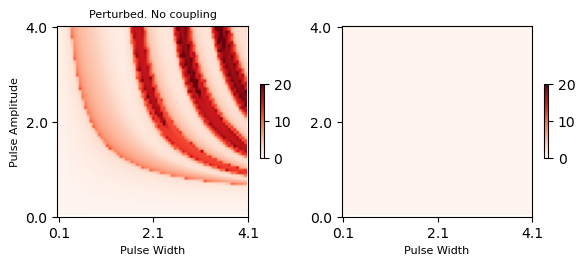

In [36]:
vmin, vmax = 0, 20

fig, ax = subplots(figsize=(6, 4), ncols=2)

im1 = ax[0].imshow(results_pert_ex1_matrix.T, cmap='Reds', vmin=vmin, vmax=vmax)

ax[0].set_xlabel('Pulse Width', fontsize=8)
ax[0].set_ylabel('Pulse Amplitude', fontsize=8)
ax[0].set_xticks(linspace(0, resolution, 3))
ax[0].set_xticklabels(around(linspace(pulse_width_min, pulse_width_max, 3),1))
ax[0].set_yticks(linspace(0, resolution, 3))
ax[0].set_yticklabels(around(linspace(pulse_ampli_min, pulse_ampli_max, 3), 2))
ax[0].set_title('Perturbed. No coupling', fontsize=8)


im2 = ax[1].imshow(results_pert_ex2_matrix.T, cmap='Reds', vmin=vmin, vmax=vmax)

ax[1].set_xlabel('Pulse Width', fontsize=8)
# ax[1].set_ylabel('Pulse Amplitude', fontsize=8)
ax[1].set_xticks(linspace(0, resolution, 3))
ax[1].set_xticklabels(around(linspace(pulse_width_min, pulse_width_max, 3), 1))
ax[1].set_yticks(linspace(0, resolution, 3))
ax[1].set_yticklabels(around(linspace(pulse_ampli_min, pulse_ampli_max, 3), 2))


fig.colorbar(im1, ax=ax[0], shrink=0.2);
fig.colorbar(im2, ax=ax[1], shrink=0.2);

fig.tight_layout()

if pars[1] == 1.5:
    
    title_chars = 'Figs/N=1/Fig_2Cb_PulsePert_SNIC.png'
    
elif pars[1] == 2.5:

    title_chars = 'PulsePert_Homoclinic_frac_E=0.0.png'

# fig.savefig(title_chars, dpi=300, format='png', bbox_inches='tight')

title_chars

In [34]:
h_ex_0, frac_E, frac_I

(-7.35, 0.0, 0.0)

# Test Code

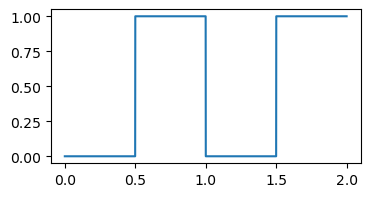

In [18]:
pulse_wid = 0.5
pulse_amp = 1.0

freq = 1

pulse_per = 1/freq
# pulse     = pulse_amp*ss.rect(mod(time, pulse_per)-pulse_per/2+pulse_wid/2, pulse_wid)
pulse     = pulse_amp*ss.rect(mod(time, pulse_per)-pulse_per/2-pulse_wid/2, pulse_wid)

fig, ax = subplots(figsize=(4, 2))

ax.plot(time[:2000], pulse[:2000]);